In [ ]:
#imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [56]:
# Load Dataset

df = pd.read_csv("Coffee_sales.csv")

df.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


In [65]:
df.info()
df = df.dropna()
df.isna().sum()


<class 'pandas.DataFrame'>
Index: 3547 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3547 non-null   str    
 1   datetime     3547 non-null   str    
 2   cash_type    3547 non-null   str    
 3   card         3547 non-null   str    
 4   money        3547 non-null   float64
 5   coffee_name  3547 non-null   str    
dtypes: float64(1), str(5)
memory usage: 194.0 KB


date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64

In [66]:
# checking duplicate rows 
df = df.drop_duplicates()
df.duplicated()[df.duplicated()==True]



Series([], dtype: bool)

NO DUPLICATES

In [67]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3547, 6) 

number of rows:  3547
number of columns:  6


In [60]:
df.dtypes

date               str
datetime           str
cash_type          str
card               str
money          float64
coffee_name        str
dtype: object

DESCRIBTIVE ANALYSIS

In [95]:
# Statistical summary
df_clean = df.dropna()

print("Statistical Summary:\n", df_clean.describe(include='all'))


Statistical Summary:
               date                 datetime cash_type                 card  \
count         3547                     3547      3547                 3547   
unique         381                     3547         1                 1316   
top     2024-10-11  2024-03-01 10:15:50.520      card  ANON-0000-0000-0012   
freq            26                        1      3547                  129   
mean           NaN                      NaN       NaN                  NaN   
std            NaN                      NaN       NaN                  NaN   
min            NaN                      NaN       NaN                  NaN   
25%            NaN                      NaN       NaN                  NaN   
50%            NaN                      NaN       NaN                  NaN   
75%            NaN                      NaN       NaN                  NaN   
max            NaN                      NaN       NaN                  NaN   

              money          coffee_name 

### Univariate Analysis

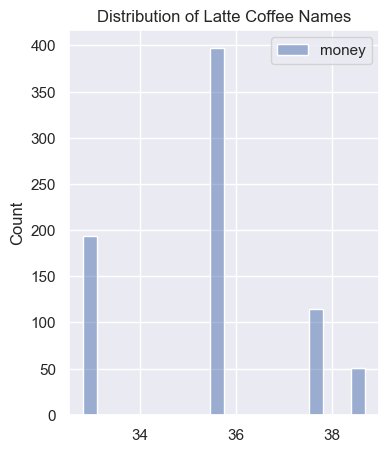

In [101]:
plt.figure(figsize=(4,5))
sns.histplot(df[df['coffee_name'] == 'Latte'], bins=20)
plt.title("Distribution of Latte Coffee Names")
plt.show()

- shows non-skewed distribution, and normal one 
- most of them are 5 to 6 rated out of 10

### Distribution of Revenue

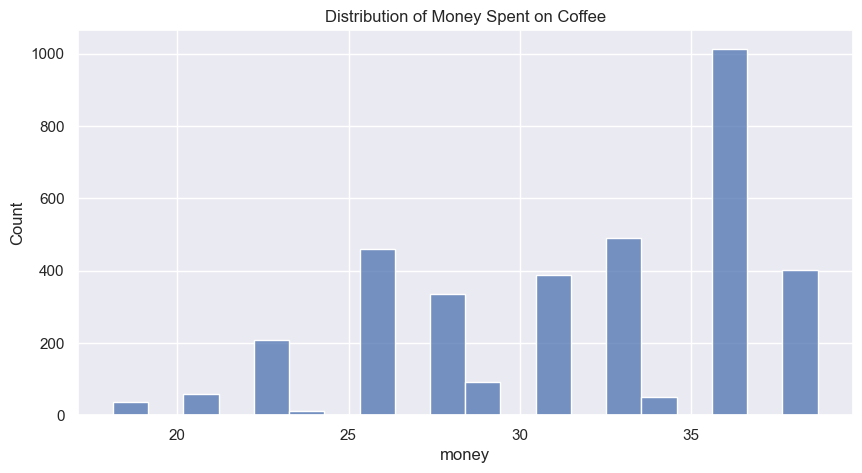

In [107]:
plt.figure(figsize=(10,5))
sns.histplot(df['money'], bins=20)
plt.title("Distribution of Money Spent on Coffee")
plt.show()

## Bivariate Analysis

### Coffees ordered more by which month


Top Coffee Sold Each Month:

      month          coffee_name  count
7   2024-03                Latte     35
9   2024-04  Americano with Milk     38
17  2024-05  Americano with Milk     54
25  2024-06  Americano with Milk     66
33  2024-07  Americano with Milk     65
41  2024-08  Americano with Milk     72
49  2024-09  Americano with Milk    104
63  2024-10                Latte    120
71  2024-11                Latte     68
73  2024-12  Americano with Milk     57
81  2025-01  Americano with Milk     52
88  2025-02            Americano    117
96  2025-03            Americano    102


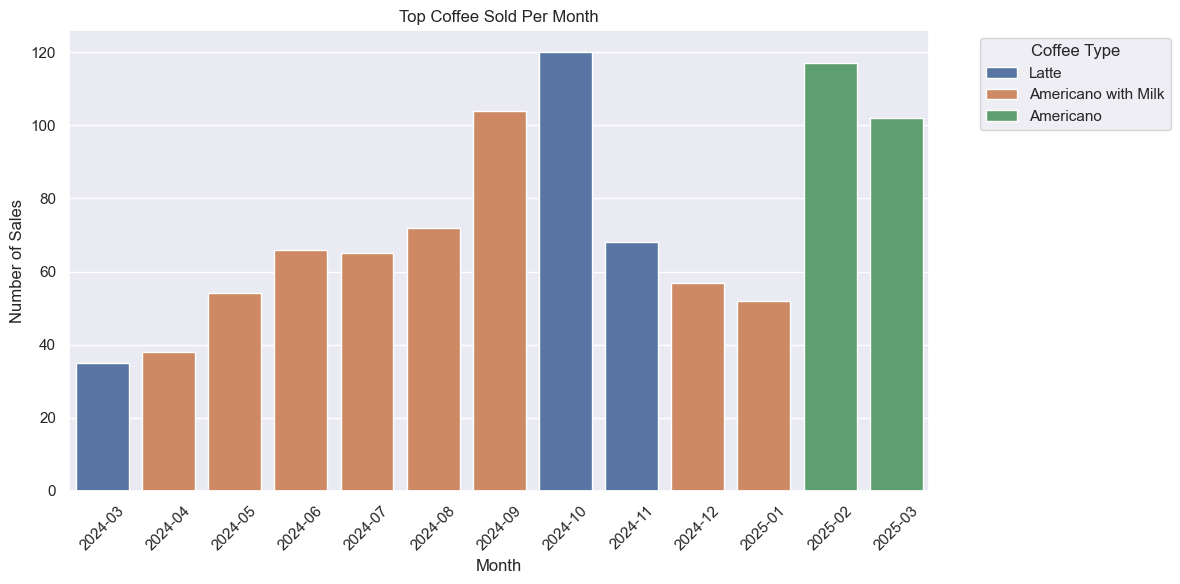

In [112]:
# Extract month from date and find top coffee per month
df['month'] = pd.to_datetime(df['date']).dt.to_period('M')

# Group by month and coffee type, count occurrences
monthly_coffee = df.groupby(['month', 'coffee_name']).size().reset_index(name='count')

# Get the coffee with highest sales per month
top_coffee_per_month = monthly_coffee.loc[monthly_coffee.groupby('month')['count'].idxmax()]

print("Top Coffee Sold Each Month:\n")
print(top_coffee_per_month)

# Visualize with a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_coffee_per_month, x='month', y='count', hue='coffee_name')
plt.title('Top Coffee Sold Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.legend(title='Coffee Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Products Revenue

Total Sales for Each Coffee Type:

           coffee_name     money
0            Americano  14650.26
1  Americano with Milk  24751.12
2           Cappuccino  17439.14
3                Cocoa   8521.16
4              Cortado   7384.86
5             Espresso   2690.28
6        Hot Chocolate   9933.46
7                Latte  26875.30


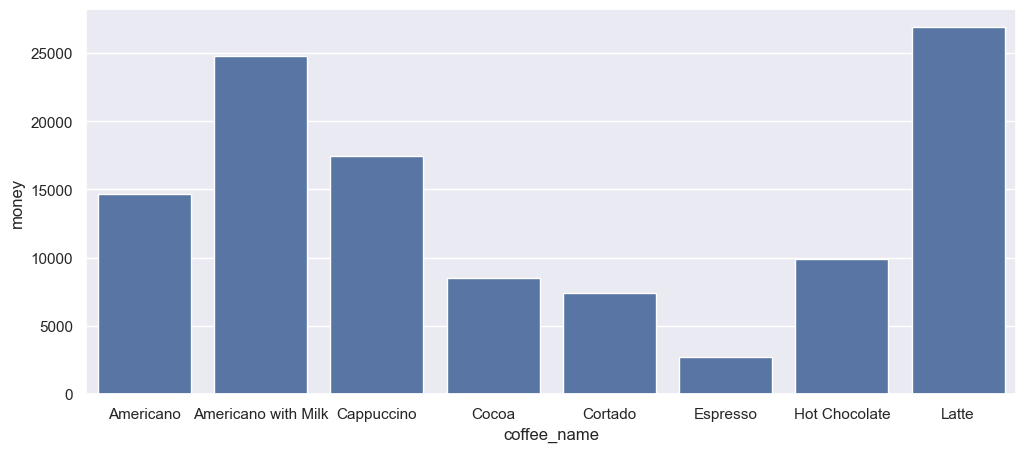

In [116]:
Coffee_types_sales = df.groupby('coffee_name')['money'].sum().reset_index()
print("Total Sales for Each Coffee Type:\n")
plt.figure(figsize=(12,5))
sns.barplot(x='coffee_name', y='money', data=Coffee_types_sales)
print(Coffee_types_sales)



### money and time corrolation

Daily Money Spending by Month:

   month_year  day_of_month  money
0     2024-03             1  396.3
1     2024-03             2  188.1
2     2024-03             3  309.1
3     2024-03             4  135.2
4     2024-03             5  338.5
5     2024-03             6  135.2
6     2024-03             7  140.1
7     2024-03             8  265.5
8     2024-03             9  439.4
9     2024-03            10   91.6
10    2024-03            11  135.2
11    2024-03            12  188.1
12    2024-03            13  231.2
13    2024-03            14  357.1
14    2024-03            15   67.6
15    2024-03            16  183.2
16    2024-03            17   28.9
17    2024-03            18  115.6
18    2024-03            19  149.9
19    2024-03            20  173.9


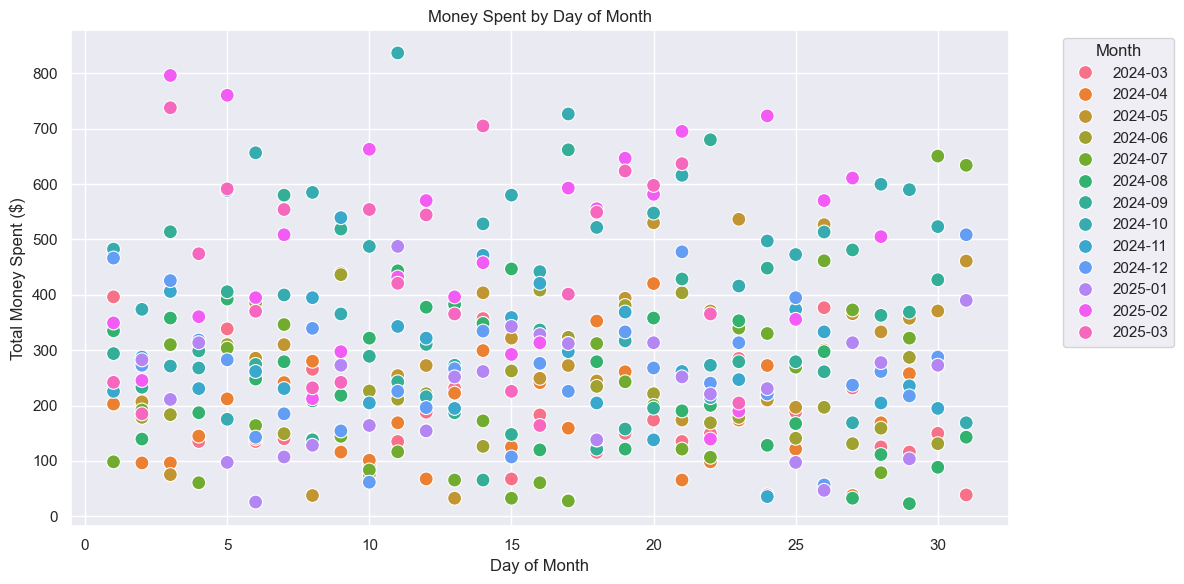

In [124]:
# Extract day of month from date
df['day_of_month'] = pd.to_datetime(df['date']).dt.day
df['month_year'] = pd.to_datetime(df['date']).dt.to_period('M')

# Group by month and day, sum the money
daily_money = df.groupby(['month_year', 'day_of_month'])['money'].sum().reset_index()
daily_money['month_year'] = daily_money['month_year'].astype(str)

print("Daily Money Spending by Month:\n")
print(daily_money.head(20))

# Scatter plot of money spent by day of month
plt.figure(figsize=(12, 6))
sns.scatterplot(data=daily_money, x='day_of_month', y='money', hue='month_year', s=100)
plt.title('Money Spent by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Total Money Spent ($)')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Corolation matrix

Correlation Matrix:

                 money  day_of_month
money         1.000000     -0.021291
day_of_month -0.021291      1.000000


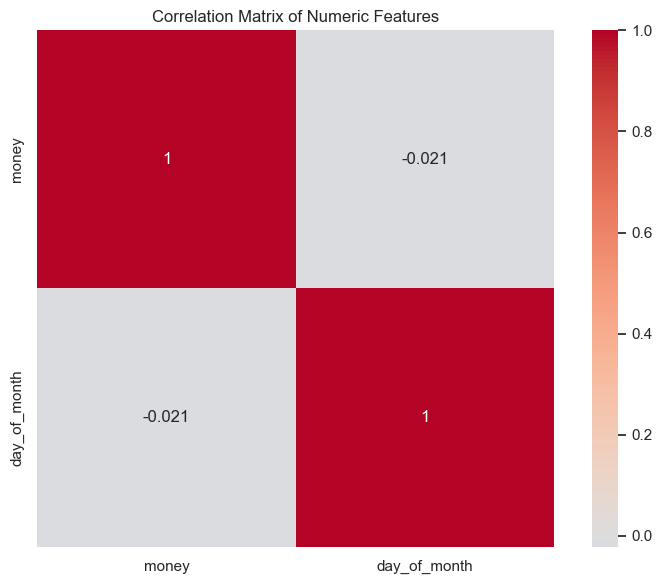


Interpretation:
- Values close to 1 = strong positive correlation
- Values close to -1 = strong negative correlation
- Values close to 0 = weak or no correlation


In [125]:
# Correlation Analysis
print("Correlation Matrix:\n")

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Visualize correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Values close to 1 = strong positive correlation")
print("- Values close to -1 = strong negative correlation")
print("- Values close to 0 = weak or no correlation")

### Monthly Revenue trend

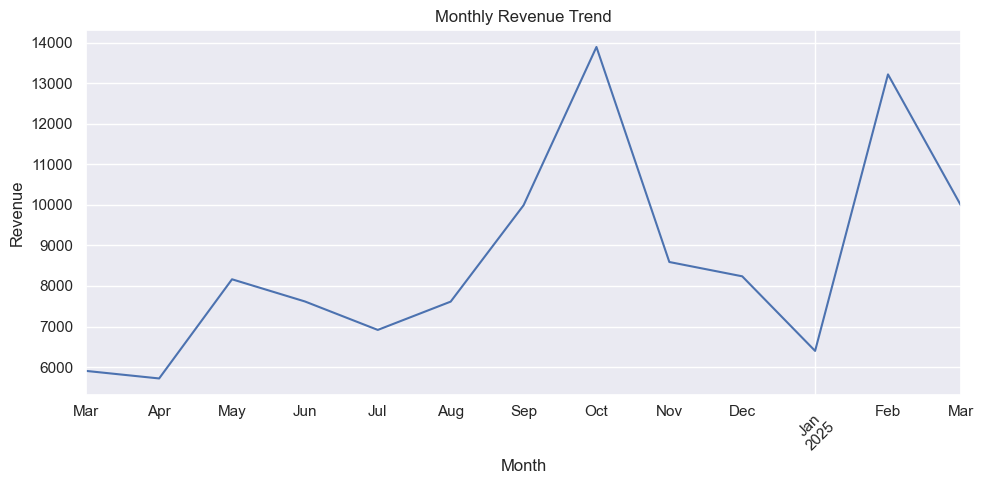

In [129]:
df['Month'] = pd.to_datetime(df['date']).dt.to_period('M')

monthly_revenue = df.groupby('Month')['money'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()